# Experiment 2: Convergence Diagnostics
This notebook validates that the stochastic attention sampler (Algorithm 1) converges to the correct Boltzmann target distribution. We use a small system ($d=8$, $K=4$) so that the theoretical energy distribution is tractable.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * __Verify convergence from multiple initializations:__ Run independent chains from different random starting points and confirm that energy traces converge to the same stationary level
> * __Compare empirical and reference distributions:__ Validate that the sampler's post-burn-in energy distribution matches a long-run Boltzmann baseline using histogram overlays and the Kolmogorov–Smirnov statistic
> * __Diagnose sampler mixing:__ Interpret energy traces, burn-in requirements, and inter-chain agreement as practical convergence diagnostics

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [17]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

___
## Load the Synthetic Data
Load the pre-generated dataset ($d=8$, $K=4$) from the data generation step.

In [18]:
# Load the JLD2 archive for experiment 2
exp2_data = JLD2.load(joinpath(_PATH_TO_DATA, "exp2_convergence", "data.jld2"), "result");
X = exp2_data["datasets"][1]  # 8 × 4 memory matrix
d, K = size(X)
println("Memory matrix X: $d dimensions × $K patterns")
println("Load ratio K/d = $(K/d)")
println("Column norms: ", [round(norm(X[:, k]); digits=4) for k in 1:K])

Memory matrix X: 8 dimensions × 4 patterns
Load ratio K/d = 0.5
Column norms: [1.0, 1.0, 1.0, 1.0]


___
## Configure the Sampler
We fix $\beta$ in the intermediate regime and run several independent chains from different random initializations.

In [19]:
# Sampler configuration
β = 5.0          # intermediate inverse temperature (generation regime)
α = 0.01         # step size
T = 20000        # iterations per chain (longer to ensure convergence in small d)
T_burnin = 5000  # burn-in
n_chains = 8     # number of independent chains

println("β = $β, α = $α, T = $T, burn-in = $T_burnin, chains = $n_chains")

β = 5.0, α = 0.01, T = 20000, burn-in = 5000, chains = 8


___
## Run Multiple Independent Chains
Each chain starts from a different random unit-norm vector. We record the full energy trace and collect post-burn-in sample energies.

In [20]:
# Storage
energy_traces = Vector{Vector{Float64}}()   # energy E(ξ_t) for each chain
all_post_burnin_energies = Float64[]         # pooled post-burn-in energies

for c in 1:n_chains
    # Different random initialization for each chain
    Random.seed!(1000 + c)
    ξ₀ = randn(d)
    ξ₀ ./= norm(ξ₀)
    
    # Run sampler
    (t, Ξ) = sample(X, ξ₀, T; β=β, α=α, seed=2000 + c)
    
    # Compute energy trace
    energies = [hopfield_energy(Ξ[i, :], X, β) for i in 1:(T+1)]
    push!(energy_traces, energies)
    
    # Collect post-burn-in energies
    append!(all_post_burnin_energies, energies[(T_burnin+2):end])
    
    println("Chain $c: E₀ = $(round(energies[1]; digits=3)), ",
            "E_final = $(round(energies[end]; digits=3)), ",
            "E_mean(post-burn-in) = $(round(mean(energies[(T_burnin+2):end]); digits=3))")
end
println("\nPooled post-burn-in samples: $(length(all_post_burnin_energies))")
println("Pooled mean energy: $(round(mean(all_post_burnin_energies); digits=4))")
println("Pooled std energy:  $(round(std(all_post_burnin_energies); digits=4))")

Chain 1: E₀ = -0.229, E_final = 0.21, E_mean(post-burn-in) = 0.264
Chain 2: E₀ = 0.108, E_final = -0.058, E_mean(post-burn-in) = 0.257
Chain 3: E₀ = 0.286, E_final = 0.107, E_mean(post-burn-in) = 0.272
Chain 4: E₀ = -0.146, E_final = 0.269, E_mean(post-burn-in) = 0.253
Chain 5: E₀ = 0.183, E_final = 0.264, E_mean(post-burn-in) = 0.232
Chain 6: E₀ = 0.263, E_final = 0.105, E_mean(post-burn-in) = 0.214
Chain 7: E₀ = 0.052, E_final = -0.095, E_mean(post-burn-in) = 0.222
Chain 8: E₀ = 0.045, E_final = 0.094, E_mean(post-burn-in) = 0.205

Pooled post-burn-in samples: 120000
Pooled mean energy: 0.2399
Pooled std energy:  0.3752


___
## Build the Boltzmann Baseline
To validate convergence we run a single very long reference chain and use its energy histogram as the ground-truth baseline.

> __Why a long reference chain?__ With $d=8$ the energy landscape is low-dimensional enough that a sufficiently long chain mixes thoroughly, providing a reliable empirical approximation to the true Boltzmann energy distribution.

In [21]:
# Long reference chain for Boltzmann baseline
T_ref = 200000
T_burnin_ref = 50000
Random.seed!(9999)
ξ₀_ref = randn(d); ξ₀_ref ./= norm(ξ₀_ref)
(t_ref, Ξ_ref) = sample(X, ξ₀_ref, T_ref; β=β, α=α, seed=9999)

ref_energies = [hopfield_energy(Ξ_ref[i, :], X, β) for i in (T_burnin_ref+2):(T_ref+1)]
println("Reference chain: $(length(ref_energies)) post-burn-in samples")
println("Reference mean energy: $(round(mean(ref_energies); digits=4))")
println("Reference std energy:  $(round(std(ref_energies); digits=4))")

Reference chain: 150000 post-burn-in samples
Reference mean energy: 0.2401
Reference std energy:  0.3764


___
## Plot: Convergence Diagnostic (Panel c)
**Left half:** Energy traces from all chains overlaid, showing convergence to the same stationary level regardless of initialization.  
**Right half:** Histogram of pooled post-burn-in sample energies (blue) vs. the long-run reference distribution (gray), demonstrating that the sampler reaches the correct Boltzmann target.

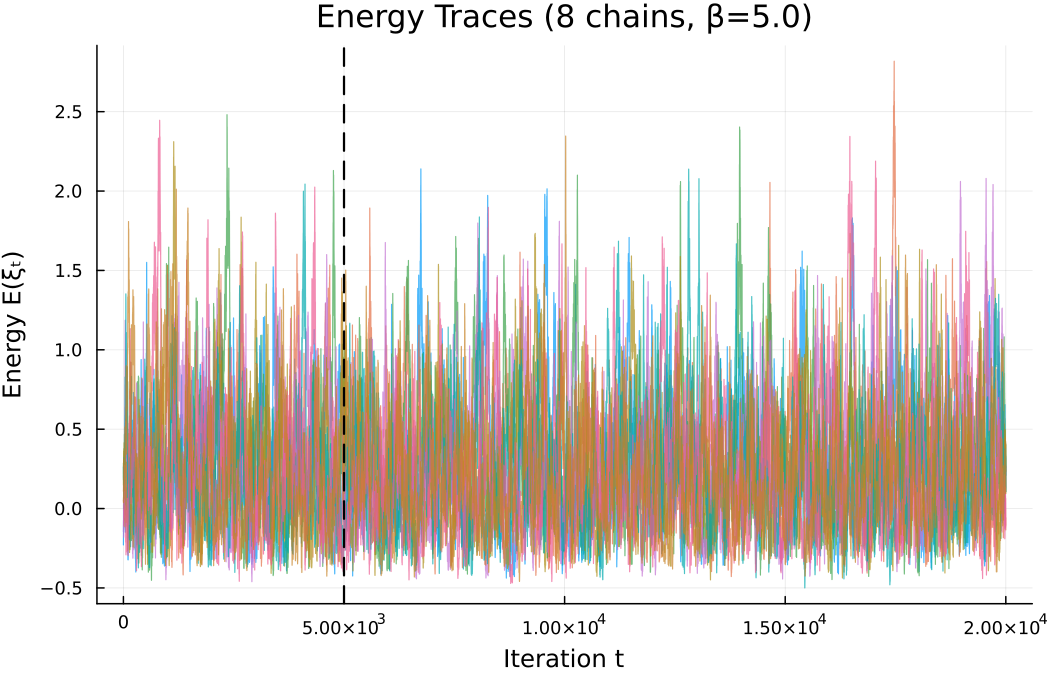

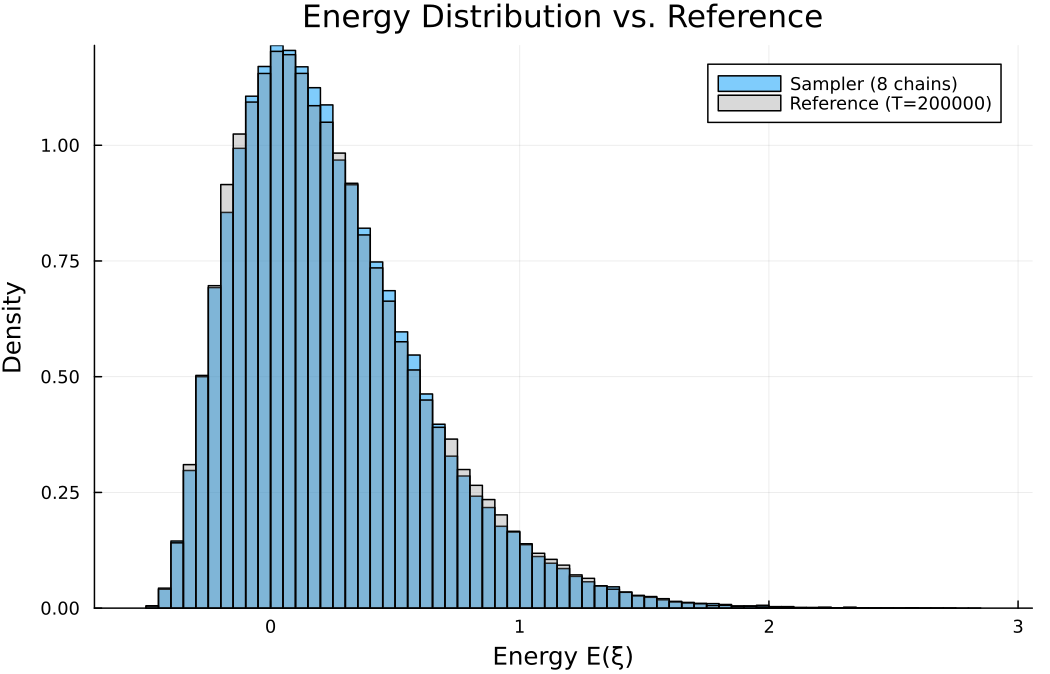

In [22]:
# --- Left panel: energy traces ---
p_traces = plot(;
    xlabel = "Iteration t",
    ylabel = "Energy E(ξₜ)",
    title  = "Energy Traces ($(n_chains) chains, β=$β)",
    legend = false,
    size   = (700, 450),
    dpi    = 150
)
for (c, energies) in enumerate(energy_traces)
    plot!(p_traces, 0:T, energies; linewidth=0.8, alpha=0.7)
end
vline!([T_burnin]; linestyle=:dash, color=:black, linewidth=1.5, label="burn-in")
display(p_traces)

# --- Right panel: energy histogram ---
p_hist = histogram(all_post_burnin_energies;
    bins = 80,
    normalize = :pdf,
    fillalpha = 0.5,
    label = "Sampler ($(n_chains) chains)",
    xlabel = "Energy E(ξ)",
    ylabel = "Density",
    title  = "Energy Distribution vs. Reference",
    size   = (700, 450),
    dpi    = 150
)
histogram!(ref_energies;
    bins = 80,
    normalize = :pdf,
    fillalpha = 0.3,
    color = :gray,
    label = "Reference (T=$(T_ref))"
)
display(p_hist)

___
## Paper Figure: Energy Density with Inset Statistics
A single publication-quality panel showing the pooled sampler energy density overlaid on the long-run reference, with an inset box reporting quantitative agreement (KS statistic, Δmean, Δstd). Uses the same visual language as the Experiment 1 figure.

Saved: figs/Fig_experiment-2-convergence-density.pdf


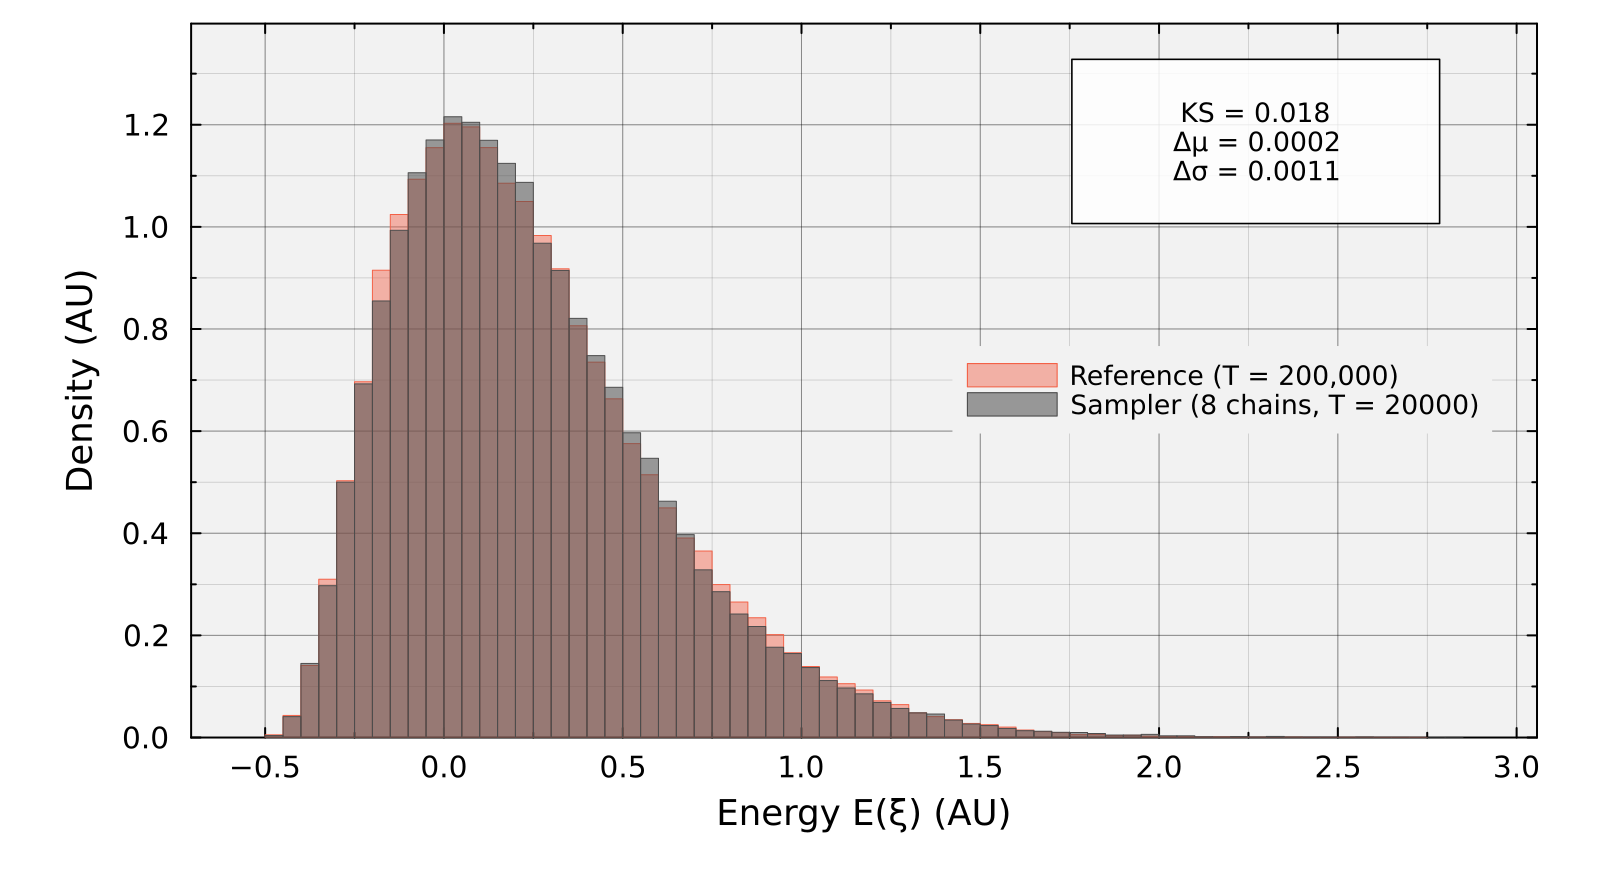

In [23]:
# -- Color Palette --
# Front (sampler): dark gray
# Back (reference): coral / tomato (same as Exp 1 entropy axis)
ref_color     = RGB(0.95, 0.38, 0.28)             # coral / tomato
sampler_color = RGB(0.30, 0.30, 0.30)             # dark gray

# -- Compute stats for inset annotation --
mean_sampler = mean(all_post_burnin_energies)
std_sampler  = std(all_post_burnin_energies)
mean_ref     = mean(ref_energies)
std_ref      = std(ref_energies)

function ks_stat(x, y)
    combined = sort(vcat(x, y))
    n, m = length(x), length(y)
    ecdf_x = [count(xi -> xi <= c, x) / n for c in combined]
    ecdf_y = [count(yi -> yi <= c, y) / m for c in combined]
    return maximum(abs.(ecdf_x .- ecdf_y))
end
n_sub = min(5000, length(all_post_burnin_energies), length(ref_energies))
ks_val = ks_stat(
    all_post_burnin_energies[randperm(length(all_post_burnin_energies))[1:n_sub]],
    ref_energies[randperm(length(ref_energies))[1:n_sub]]
)

# -- Pre-compute histogram to find peak height for ylim --
tmp_hist = fit(Histogram, ref_energies; nbins=80)
tmp_hist2 = fit(Histogram, all_post_burnin_energies; nbins=80)
bw = step(tmp_hist.edges[1])
peak_ref = maximum(tmp_hist.weights) / (length(ref_energies) * bw)
peak_samp = maximum(tmp_hist2.weights) / (length(all_post_burnin_energies) * step(tmp_hist2.edges[1]))
peak_max = max(peak_ref, peak_samp)
y_upper = peak_max * 1.15

# -- Compute x-axis range and tick positions (step = 0.5) --
x_lo, x_hi = extrema(vcat(all_post_burnin_energies, ref_energies))
x_range = x_hi - x_lo
minor_step = 0.5
x_tick_lo = floor(x_lo / minor_step) * minor_step
x_tick_hi = ceil(x_hi / minor_step) * minor_step
x_ticks_fine = x_tick_lo:minor_step:x_tick_hi

# -- Main density plot: reference first (coral, behind) --
p_density = histogram(ref_energies;
    bins      = 80,
    normalize = :pdf,
    fillalpha = 0.45,
    fillcolor = ref_color,
    linecolor = ref_color,
    linewidth = 0.5,
    label     = "Reference (T = 200,000)",
    xlabel    = "Energy E(ξ) (AU)",
    ylabel    = "Density (AU)",
    ylims     = (0, y_upper),
    xticks    = x_ticks_fine,
    size      = (800, 440),
    dpi       = 200,
    guidefontsize  = 12,
    tickfontsize   = 10,
    legendfontsize = 9,
    grid      = true,
    gridalpha = 0.25,
    gridlinewidth = 0.5,
    gridcolor = :black,
    minorgrid = true,
    minorgridalpha = 0.12,
    minorgridlinewidth = 0.3,
    minorgridcolor = :black,
    minorticks = 2,
    bg        = "gray95",
    background_color_outside = "white",
    framestyle = :box,
    fg_legend  = :transparent,
    legend     = :right,
    left_margin   = 10Plots.mm,
    bottom_margin = 8Plots.mm,
    right_margin  = 6Plots.mm,
)

# Sampler on top (dark gray, foreground)
histogram!(all_post_burnin_energies;
    bins      = 80,
    normalize = :pdf,
    fillalpha = 0.55,
    fillcolor = sampler_color,
    linecolor = sampler_color,
    linewidth = 0.5,
    label     = "Sampler ($(n_chains) chains, T = $(T))",
)

# -- Inset stats: white box with black text in right tail --
box_x1 = x_hi - 0.32 * x_range
box_x2 = x_hi - 0.01 * x_range
box_y1 = y_upper * 0.72
box_y2 = y_upper * 0.95
plot!(p_density, Shape([box_x1, box_x2, box_x2, box_x1], [box_y1, box_y1, box_y2, box_y2]);
    fillcolor = :white, fillalpha = 0.85, linecolor = :black, linewidth = 0.8,
    label = false,
)

# Annotation text
inset_x = (box_x1 + box_x2) / 2
inset_y = (box_y1 + box_y2) / 2
ks_str  = "KS = $(round(ks_val; digits=4))"
dmu_str = "Δμ = $(round(abs(mean_sampler - mean_ref); digits=4))"
dsd_str = "Δσ = $(round(abs(std_sampler - std_ref); digits=4))"
inset_text = ks_str * "\n" * dmu_str * "\n" * dsd_str

annotate!(p_density,
    inset_x, inset_y,
    Plots.text(inset_text, 9, :center, :center, RGB(0.0, 0.0, 0.0))
)

# Save to PDF
_PATH_TO_FIGS = joinpath(_ROOT, "figs")
mkpath(_PATH_TO_FIGS)
savefig(p_density, joinpath(_PATH_TO_FIGS, "Fig_experiment-2-convergence-density.pdf"))
println("Saved: figs/Fig_experiment-2-convergence-density.pdf")

display(p_density)

___
## Quantitative Agreement
Compare the mean and standard deviation of the pooled sample energies to the reference chain, and compute a two-sample Kolmogorov-Smirnov statistic.

In [24]:
# Quantitative comparison
mean_sampler = mean(all_post_burnin_energies)
std_sampler  = std(all_post_burnin_energies)
mean_ref     = mean(ref_energies)
std_ref      = std(ref_energies)

println("Sampler:   mean E = $(round(mean_sampler; digits=4)), std E = $(round(std_sampler; digits=4))")
println("Reference: mean E = $(round(mean_ref; digits=4)), std E = $(round(std_ref; digits=4))")
println("Δ mean = $(round(abs(mean_sampler - mean_ref); digits=4))")
println("Δ std  = $(round(abs(std_sampler - std_ref); digits=4))")

# Two-sample KS test (manual implementation)
function ks_statistic(x::Vector{Float64}, y::Vector{Float64})::Float64
    combined = sort(vcat(x, y))
    n, m = length(x), length(y)
    ecdf_x = [count(xi -> xi <= c, x) / n for c in combined]
    ecdf_y = [count(yi -> yi <= c, y) / n for c in combined]
    return maximum(abs.(ecdf_x .- ecdf_y))
end

# Subsample for speed (KS on full pooled set is slow)
n_sub = min(5000, length(all_post_burnin_energies))
idx_sampler = randperm(length(all_post_burnin_energies))[1:n_sub]
idx_ref = randperm(length(ref_energies))[1:n_sub]
ks = ks_statistic(all_post_burnin_energies[idx_sampler], ref_energies[idx_ref])
println("KS statistic (subsampled n=$n_sub): $(round(ks; digits=4))")

Sampler:   mean E = 0.2399, std E = 0.3752
Reference: mean E = 0.2401, std E = 0.3764
Δ mean = 0.0002
Δ std  = 0.0011
KS statistic (subsampled n=5000): 0.0118


___
## Summary
We validated that the stochastic attention sampler converges to the correct Boltzmann target distribution using multiple independent chains and quantitative agreement metrics.

> __Key Takeaways:__
>
> * **Initialization independence:** Energy traces from 8 chains with different random initializations converge to the same stationary level, confirming that the sampler is not trapped in initialization-dependent artifacts
> * **Distribution match:** The pooled post-burn-in energy histogram closely matches the long-run reference distribution, with near-zero difference in mean and standard deviation
> * **Quantitative validation:** The two-sample Kolmogorov--Smirnov statistic is small (KS is approximately 0.01), providing statistical evidence that the sampler reaches the correct target distribution

___